<a href="https://colab.research.google.com/github/ThiagoDamasz/capacitacao-IA-CS-I/blob/main/Modelo_Media_Movel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Modelo de Média Móvel

Este modelo calcula a média de observações passadas para prever valores futuros. Ele é útil para capturar flutuações de curto prazo e variações aleatórias nos dados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
path = '/content/drive/MyDrive/aprendendo-series-temporais/data/precipitacionsbcndesde1786_2024.csv'

In [ ]:
df_precipitacion = pd.read_csv(path)

In [ ]:
df_precipitacion

,Any,Precip_Acum_Gener,Precip_Acum_Febrer,Precip_Acum_Marc,Precip_Acum_Abril,Precip_Acum_Maig,Precip_Acum_Juny,Precip_Acum_Juliol,Precip_Acum_Agost,Precip_Acum_Setembre,Precip_Acum_Octubre,Precip_Acum_Novembre,Precip_Acum_Desembre
0,1786,32.8,28.4,84.4,42.3,8.5,38.0,6.8,52.1,62.0,57.0,195.8,114.1
1,1787,136.4,27.4,44.6,76.9,0.0,29.8,34.7,14.9,205.8,12.4,42.2,0.0
2,1788,9.9,14.9,32.2,12.4,7.5,146.3,59.4,29.8,123.9,163.6,106.6,22.3
3,1789,12.4,12.4,23.6,9.9,32.2,9.9,6.3,69.4,18.7,52.1,18.7,76.9
4,1790,44.6,1.2,188.5,74.4,44.7,39.7,65.7,32.3,71.9,205.8,72.0,14.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,2020,89.3,2.8,61.6,258.7,29.2,69.1,23.1,12.4,60.2,23.1,52.5,41.5
235,2021,26.2,26.5,7.7,62.7,13.4,7.8,9.0,8.3,23.3,63.2,75.9,3.8
236,2022,12.3,1.9,89.5,38.9,20.0,9.5,2.7,67.9,13.1,11.3,7.6,33.0
237,2023,8.7,40.7,1.0,36.0,46.5,39.8,6.2,44.6,50.4,29.2,3.7,2.7


## ACF (Função de autocorrelação)

A ACF mede a força da relação entre o valor de hoje e os valores dos dias anteriores (chamados de lags ou defasagens), sem filtrar as influências dos dias do meio.



## PACF (Função de autocorrelação parcial)

A PACF é mais "ciumenta" e rigorosa. Ela mede a correlação entre o dia de hoje e um dia específico no passado, removendo todo o impacto dos dias intermediários. Ela quer saber o efeito puro e direto.


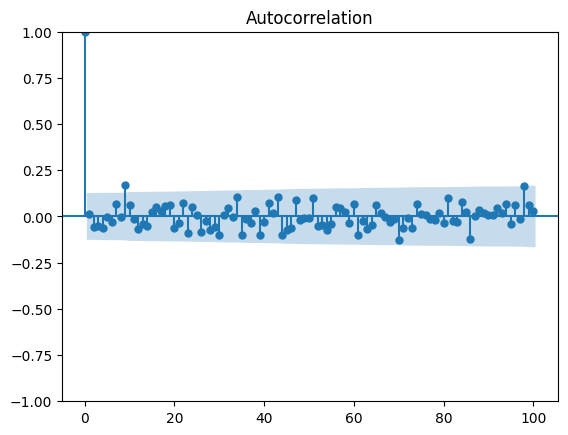

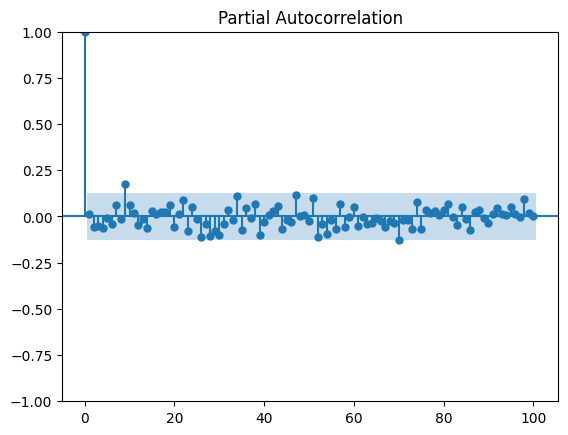

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Plot ACF
plot_acf(df_precipitacion['Precip_Acum_Gener'], lags=100)
plt.show()

# Plot PACF
plot_pacf(df_precipitacion['Precip_Acum_Gener'], lags=100)
plt.show()

In [ ]:
df_precipitacion['Any'] = pd.to_datetime(df_precipitacion['Any'], format='%Y') # Transforma a coluna de anos para o formato date-time do pandas
yearly_precipitation = df_precipitacion.groupby('Any')['Precip_Acum_Gener'].sum() # Soma todas as precipitações dos anos que aparecem mais de uma vez e gera uma series do pandas
yearly_precipitation = yearly_precipitation.reset_index() # Transforma a series do pandas em uma coluna de dataframe novamente

In [ ]:
idx = 219
train = yearly_precipitation[0:idx] # Conjunto de treinamento
valid = yearly_precipitation[idx:] # Conjunto de teste

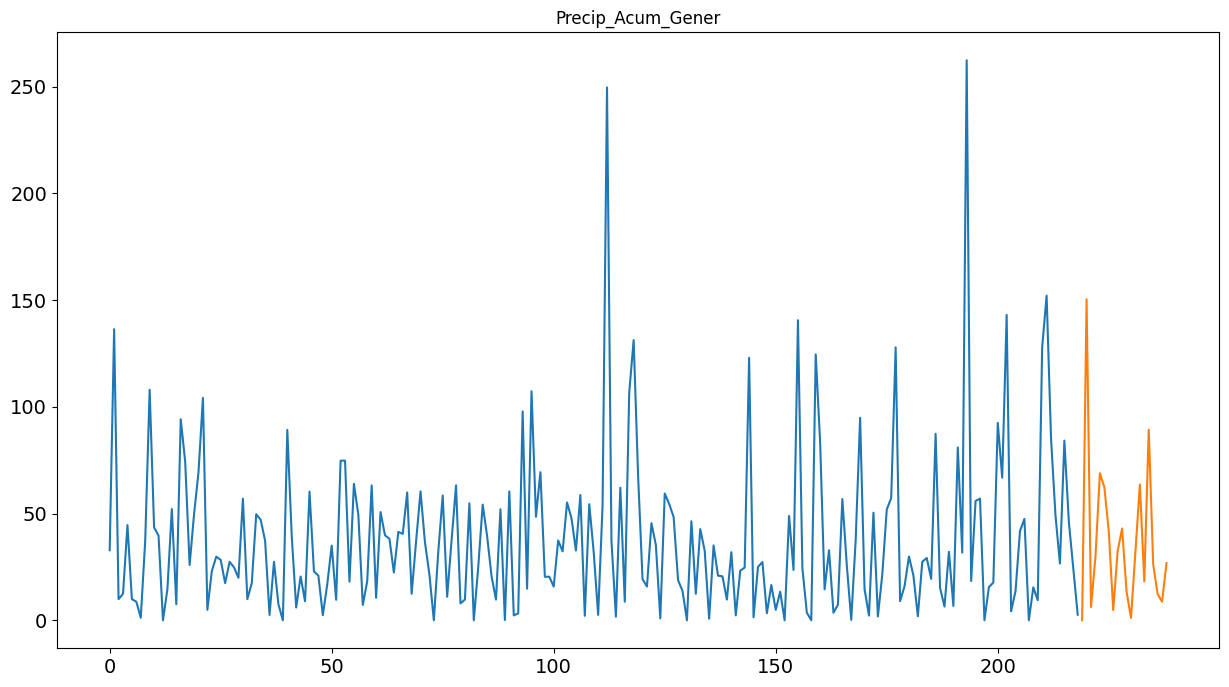

In [ ]:
train['Precip_Acum_Gener'].plot(figsize=(15,8), title= 'Precip_Acum_Gener', fontsize=14)
valid['Precip_Acum_Gener'].plot(figsize=(15,8), title= 'Precip_Acum_Gener', fontsize=14)
plt.show()

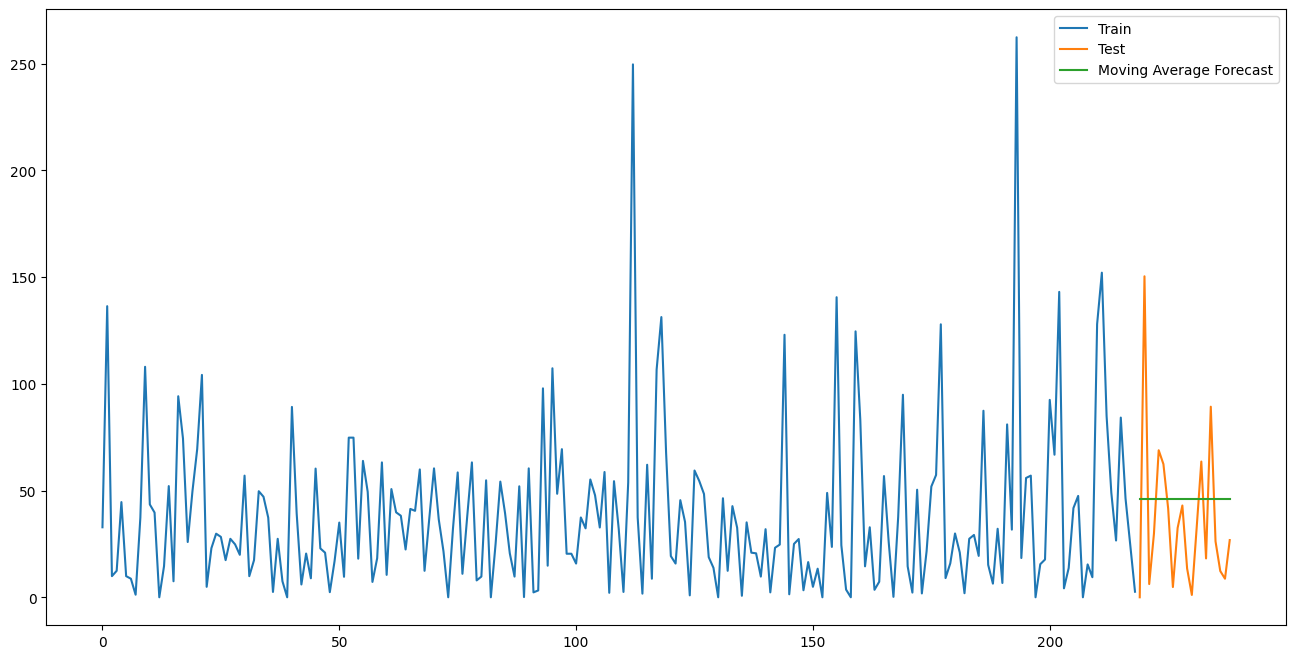

In [ ]:
y_hat_avg = valid.copy()
y_hat_avg['Precip_Acum_Gener'] = train['Precip_Acum_Gener'].rolling(50).mean().iloc[-1] # Aplica o modelo médio de previsão para calcular a média dos últimos 50 anos e assume que o futuro será igual.
plt.figure(figsize=(16,8))
plt.plot(train['Precip_Acum_Gener'], label='Train')
plt.plot(valid['Precip_Acum_Gener'], label='Test')
plt.plot(y_hat_avg['Precip_Acum_Gener'], label='Moving Average Forecast')
plt.legend(loc='best')
plt.show()

In [ ]:

from sklearn.metrics import mean_squared_error
from math import sqrt
rms = sqrt(mean_squared_error(valid['Precip_Acum_Gener'], y_hat_avg['Precip_Acum_Gener']))
print(rms)

36.77607978020497


O Erro da média móvel cálculado foi muuito grande, isso acontece pois os dados do conjunto de validação estão muito esparços.

In [ ]:
import os

caminho_modelo = '/content/drive/MyDrive/aprendendo-series-temporais/'
pasta_models = os.path.join(caminho_modelo, 'models')